# YOLO + ST-GCN Inference Pipeline
End-to-end human action recognition on Penn Action dataset.

**Flow**: YOLOv8-pose (pose estimation) → COCO→Penn joint remapping → ST-GCN (action classification)

**Requirements**: trained weights saved at `MyDrive/Colab_STGCN_Weights/stgcn_penn_action.pth`

In [ ]:
import subprocess, sys, os
import zipfile # Import zipfile for dataset extraction

# Install dependencies
# Removed 'kaggle' and added 'gdown'
subprocess.run([sys.executable, '-m', 'pip', 'install', 'gdown', 'ultralytics', '-q'], check=True)

# Mount Google Drive (still mounted for other potential uses, though weights are no longer there)
from google.colab import drive
drive.mount('/content/drive')

DOWNLOAD_DIR = '/content/penn_action'

# --- Dataset Download (from Google Drive link) ---
DATASET_GD_ID = '15SLfJN2pa-UsvILdaOVH0CuhbS-Zd2yk'
DATASET_ZIP_PATH = os.path.join(DOWNLOAD_DIR, 'penn-action-dataset.zip')
DATASET_EXTRACT_PATH = DOWNLOAD_DIR # Unzip directly into DOWNLOAD_DIR which will create Penn_Action/

if os.path.exists(os.path.join(DATASET_EXTRACT_PATH, 'Penn_Action')):
    print('Penn Action dataset already exists in Colab environment. Skipping download.')
else:
    print('Downloading Penn Action dataset from Google Drive...')
    os.makedirs(DOWNLOAD_DIR, exist_ok=True)
    import gdown # gdown is used for Google Drive downloads
    gdown.download(id=DATASET_GD_ID, output=DATASET_ZIP_PATH, quiet=False)
    print(f'Unzipping {DATASET_ZIP_PATH}...')
    with zipfile.ZipFile(DATASET_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(DATASET_EXTRACT_PATH)
    print('Dataset unzipped.')
    os.remove(DATASET_ZIP_PATH) # Clean up the zip file

# --- Model Weights Download (from Hugging Face) ---
WEIGHTS_HF_URL = 'https://huggingface.co/MatchaMacchiato/st-gcn-v1/resolve/main/stgcn_penn_action.pth'
LOCAL_WEIGHTS_PATH = '/content/stgcn_penn_action.pth'

if os.path.exists(LOCAL_WEIGHTS_PATH):
    print('ST-GCN weights already downloaded. Skipping download.')
else:
    print('Downloading ST-GCN weights from Hugging Face...')
    # Using subprocess with wget for direct file download
    subprocess.run(['wget', '-O', LOCAL_WEIGHTS_PATH, WEIGHTS_HF_URL], check=True)
    print('Weights downloaded.')

# Paths
DATA_DIR     = os.path.join(DOWNLOAD_DIR, 'Penn_Action')
LABELS_DIR   = os.path.join(DATA_DIR, 'labels')
FRAMES_DIR   = os.path.join(DATA_DIR, 'frames')
WEIGHTS_PATH = LOCAL_WEIGHTS_PATH # Updated to local path

import glob, scipy.io
import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device          : {device}')
print(f'Labels dir ok   : {os.path.exists(LABELS_DIR)}')
print(f'Frames dir ok   : {os.path.exists(FRAMES_DIR)}')
print(f'Weights found   : {os.path.exists(WEIGHTS_PATH)}')

Mounted at /content/drive


Downloading...
From (original): https://drive.google.com/uc?id=15SLfJN2pa-UsvILdaOVH0CuhbS-Zd2yk
From (redirected): https://drive.google.com/uc?id=15SLfJN2pa-UsvILdaOVH0CuhbS-Zd2yk&confirm=t&uuid=4d64af56-702d-4eac-b24c-2e2702e7f7ad
To: /content/penn_action/penn-action-dataset.zip
100%|██████████| 3.44G/3.44G [00:54<00:00, 62.8MB/s]


Unzipping /content/penn_action/penn-action-dataset.zip...
Dataset unzipped.
Weights downloaded.
Device          : cuda
Labels dir ok   : True
Frames dir ok   : True
Weights found   : True


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

exercise_classes = [
    'bench_press', 'clean_and_jerk', 'jump_rope', 'jumping_jacks',
    'pullup', 'pushup', 'situp', 'squat'
]
class_to_id = {c: i for i, c in enumerate(exercise_classes)}

# ── Preprocessing helpers (must match training exactly) ───────────────
def add_virtual_center_joint(kpts):
    """kpts: (T, 13, 2) → (T, 14, 2).  Joint 13 = mean of l_sho,r_sho,l_hip,r_hip."""
    center = (kpts[:, 1, :] + kpts[:, 2, :] + kpts[:, 7, :] + kpts[:, 8, :]) / 4.0
    return np.concatenate((kpts, center[:, np.newaxis, :]), axis=1)

def temporal_align(kpts, target_frames=64):
    """Resample sequence to exactly target_frames via uniform index sampling."""
    T = kpts.shape[0]
    if T == target_frames:
        return kpts
    indices = np.linspace(0, T - 1, target_frames).astype(int)
    return kpts[indices]

# ── Graph ─────────────────────────────────────────────────────────────
class Graph_PennAction_14Nodes:
    def __init__(self):
        self.num_node   = 14
        self.center_node = 13
        self.edges = [
            (0,1),(0,2),(1,3),(3,5),(2,4),(4,6),
            (1,7),(2,8),(7,8),(7,9),(9,11),(8,10),(10,12),
            (1,13),(2,13),(7,13),(8,13)
        ]
        self.A = self._build_A()

    def _hop_distance(self):
        A = np.zeros((self.num_node, self.num_node))
        for i, j in self.edges:
            A[i, j] = A[j, i] = 1
        hop = np.full((self.num_node, self.num_node), np.inf)
        mats = [np.linalg.matrix_power(A, d) for d in range(self.num_node)]
        for d in range(self.num_node - 1, -1, -1):
            hop[np.stack(mats)[d] > 0] = d
        return hop

    def _build_A(self):
        hop = self._hop_distance()
        dist_to_center = hop[self.center_node]
        A = np.zeros((3, self.num_node, self.num_node))
        for i, j in self.edges:
            A[0, i, i] = A[0, j, j] = 1
            if dist_to_center[i] > dist_to_center[j]:
                A[1, j, i] = 1; A[2, i, j] = 1
            elif dist_to_center[i] < dist_to_center[j]:
                A[1, i, j] = 1; A[2, j, i] = 1
            else:
                A[0, i, j] = A[0, j, i] = 1
        for k in range(3):
            D = np.diag(A[k].sum(axis=1))
            D_inv = np.zeros_like(D)
            D_inv[D > 0] = 1.0 / D[D > 0]
            A[k] = A[k] @ D_inv
        return torch.tensor(A, dtype=torch.float32)

# ── ST-GCN Block ──────────────────────────────────────────────────────
class STGCN_Block(nn.Module):
    def __init__(self, in_ch, out_ch, A, stride=1, residual=True):
        super().__init__()
        self.K = A.size(0)
        self.A = nn.Parameter(A, requires_grad=False)
        self.gcn = nn.Conv2d(in_ch, out_ch * self.K, kernel_size=1)
        self.tcn = nn.Conv2d(out_ch, out_ch, kernel_size=(9,1),
                             padding=(4,0), stride=(stride,1))
        if not residual:
            self.res = lambda x: 0
        elif in_ch == out_ch and stride == 1:
            self.res = lambda x: x
        else:
            self.res = nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=(stride,1))
        self.relu = nn.ReLU()

    def forward(self, x):
        N, C, T, V = x.size()
        r = self.res(x)
        x = self.gcn(x).view(N, self.K, -1, T, V)
        x = torch.einsum('nkctv,kvw->nctw', x, self.A)
        x = self.tcn(x)
        return self.relu(x + r)

# ── ST-GCN Model ──────────────────────────────────────────────────────
class Model_STGCN(nn.Module):
    def __init__(self, num_classes=8, in_channels=2):
        super().__init__()
        self.graph = Graph_PennAction_14Nodes()
        A = self.graph.A
        self.data_bn = nn.BatchNorm1d(in_channels * self.graph.num_node)
        self.st_gcn_networks = nn.ModuleList([
            STGCN_Block(in_channels, 64,  A, residual=False),
            STGCN_Block(64,  64,  A),
            STGCN_Block(64,  128, A, stride=2),
            STGCN_Block(128, 128, A),
            STGCN_Block(128, 256, A, stride=2),
            STGCN_Block(256, 256, A),
        ])
        self.fcn = nn.Conv2d(256, num_classes, kernel_size=1)

    def forward(self, x):
        N, C, T, V, M = x.size()
        x = x.permute(0,4,3,1,2).contiguous().view(N, M*V*C, T)
        x = self.data_bn(x)
        x = x.view(N,M,V,C,T).permute(0,1,3,4,2).contiguous().view(N*M, C, T, V)
        for gcn in self.st_gcn_networks:
            x = gcn(x)
        x = F.avg_pool2d(x, x.size()[2:])
        x = x.view(N, M, -1, 1, 1).mean(dim=1)
        return self.fcn(x).view(x.size(0), -1)

print('Model classes defined.')


Model classes defined.


In [ ]:
from ultralytics import YOLO

# Load trained ST-GCN
model_stgcn = Model_STGCN(num_classes=8, in_channels=2).to(device)

# Load the state_dict and remap keys to match the current model definition
state_dict = torch.load(WEIGHTS_PATH, map_location=device)
new_state_dict = {}
for k, v in state_dict.items():
    if 'gcn_conv' in k:
        new_k = k.replace('gcn_conv', 'gcn')
    elif 'tcn_conv' in k:
        new_k = k.replace('tcn_conv', 'tcn')
    elif 'residual' in k: # Handle residual for blocks where self.res is an nn.Conv2d
        new_k = k.replace('residual', 'res')
    else:
        new_k = k
    new_state_dict[new_k] = v

model_stgcn.load_state_dict(new_state_dict)
model_stgcn.eval()
print('ST-GCN weights loaded.')

# Load YOLOv8-pose (auto-downloads yolov8n-pose.pt ~6MB)
model_yolo = YOLO('yolov8n-pose.pt')
print('YOLOv8-pose loaded.')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ST-GCN weights loaded.
YOLOv8-pose loaded.


Demo video: 0341  |  GT action: bench_press
Predicted: bench_press  |  GT: bench_press  ✓


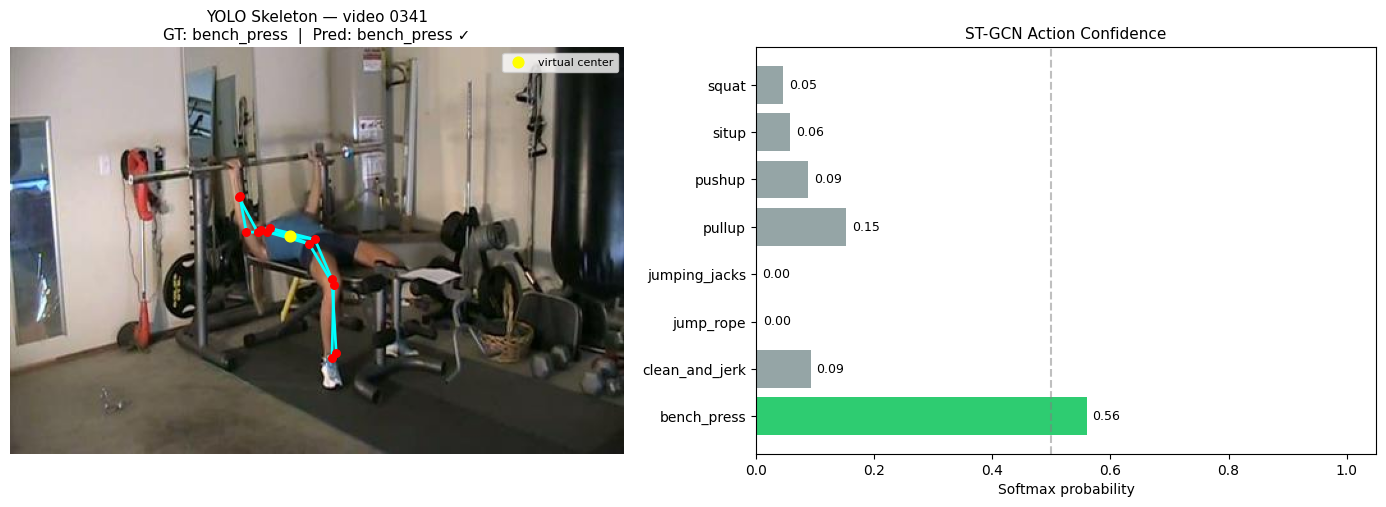

In [ ]:
# COCO keypoint index → Penn Action joint index
# Drop COCO 1,2,3,4 (eyes/ears); keep [0,5..16] → remap to Penn Action 0..12
COCO_TO_PENN_IDX = [0, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

# 14-joint bone pairs for visualization (includes virtual center joint 13)
PENN_BONES_14 = [
    (0,1),(0,2),(1,3),(3,5),(2,4),(4,6),
    (1,7),(2,8),(7,8),(7,9),(9,11),(8,10),(10,12),
    (1,13),(2,13),(7,13),(8,13)
]

def extract_yolo_keypoints(frames_dir, video_id, model_yolo, target_frames=64):
    """Run YOLO on all frames of a video.
    Returns (target_frames, 14, 2) aligned keypoints, or None if no frames found.
    """
    frame_paths = sorted(glob.glob(os.path.join(frames_dir, video_id, '*.jpg')))
    if not frame_paths:
        return None, []
    kpts_seq = []
    for fp in frame_paths:
        results = model_yolo(fp, verbose=False)
        if results[0].keypoints is not None and len(results[0].keypoints.xy) > 0:
            kp17 = results[0].keypoints.xy[0].cpu().numpy()  # (17, 2)
            kp13 = kp17[COCO_TO_PENN_IDX]                    # (13, 2)
        else:
            kp13 = np.zeros((13, 2))  # no person detected in this frame
        kpts_seq.append(kp13)
    kpts    = np.array(kpts_seq)             # (T, 13, 2)
    kpts14  = add_virtual_center_joint(kpts) # (T, 14, 2)
    aligned = temporal_align(kpts14, target_frames)  # (64, 14, 2)
    return aligned, frame_paths

def run_stgcn_inference(kpts_aligned, model_stgcn, device):
    """(64, 14, 2) → (predicted_class_idx, softmax_probs array len 8)."""
    tensor = np.transpose(kpts_aligned, (2, 0, 1))          # (2, 64, 14)
    tensor = np.expand_dims(tensor, axis=(0, -1))            # (1, 2, 64, 14, 1)
    x = torch.FloatTensor(tensor).to(device)
    with torch.no_grad():
        probs = torch.softmax(model_stgcn(x), dim=1).cpu().numpy()[0]  # (8,)
    return int(np.argmax(probs)), probs

# ── Demo: run full pipeline on one exercise video ──────────────────────
mat_files_all = sorted(glob.glob(os.path.join(LABELS_DIR, '*.mat')))

demo_mat = demo_vid = demo_gt = None
for mf in mat_files_all:
    md = scipy.io.loadmat(mf)
    action = md['action'][0]
    if isinstance(action, np.ndarray): action = action[0]
    action = str(action)
    if action not in exercise_classes:
        continue
    vid = os.path.splitext(os.path.basename(mf))[0]
    if sorted(glob.glob(os.path.join(FRAMES_DIR, vid, '*.jpg'))):
        demo_mat, demo_vid, demo_gt = mf, vid, action
        break

print(f'Demo video: {demo_vid}  |  GT action: {demo_gt}')

kpts_aligned, frame_paths = extract_yolo_keypoints(FRAMES_DIR, demo_vid, model_yolo)
pred_idx, probs = run_stgcn_inference(kpts_aligned, model_stgcn, device)
pred_action = exercise_classes[pred_idx]
correct = '✓' if pred_action == demo_gt else '✗'
print(f'Predicted: {pred_action}  |  GT: {demo_gt}  {correct}')

# ── Visualization: first frame skeleton + confidence bar ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: frame with YOLO skeleton
frame_bgr = cv2.imread(frame_paths[0])
frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
res0 = model_yolo(frame_paths[0], verbose=False)
if res0[0].keypoints is not None and len(res0[0].keypoints.xy) > 0:
    kp17 = res0[0].keypoints.xy[0].cpu().numpy()  # (17,2)
    kp13 = kp17[COCO_TO_PENN_IDX]                 # (13,2)
    center = (kp13[1]+kp13[2]+kp13[7]+kp13[8]) / 4.0
    kp14 = np.vstack([kp13, center])               # (14,2)
    axes[0].imshow(frame_rgb)
    for i, j in PENN_BONES_14:
        if kp14[i].sum() > 0 and kp14[j].sum() > 0:
            axes[0].plot([kp14[i,0], kp14[j,0]], [kp14[i,1], kp14[j,1]],
                         color='cyan', linewidth=2)
    axes[0].scatter(kp14[:,0], kp14[:,1], c='red', s=30, zorder=5)
    axes[0].scatter([kp14[13,0]], [kp14[13,1]], c='yellow', s=60,
                    zorder=6, label='virtual center')
    axes[0].legend(fontsize=8)
axes[0].set_title(f'YOLO Skeleton — video {demo_vid}\n'
                  f'GT: {demo_gt}  |  Pred: {pred_action} {correct}', fontsize=11)
axes[0].axis('off')

# Right: confidence bar chart
colors = ['#2ecc71' if i == pred_idx else '#95a5a6' for i in range(8)]
axes[1].barh(exercise_classes, probs, color=colors)
axes[1].set_xlim(0, 1.05)
axes[1].set_title('ST-GCN Action Confidence', fontsize=11)
axes[1].set_xlabel('Softmax probability')
axes[1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
for i, p in enumerate(probs):
    axes[1].text(p + 0.01, i, f'{p:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('yolo_stgcn_demo.png', dpi=150, bbox_inches='tight')
plt.show()


Evaluating YOLO keypoint quality vs .mat ground truth...
(Running YOLO on every exercise video — this takes several minutes)



Evaluating YOLO keypoint quality:   0%|          | 0/2326 [00:00<?, ?it/s]

Evaluated : 1158 videos
Skipped   : 5 (no frames or no YOLO detections)

Overall mean normalised joint error: 3.3715
Per-joint errors:
  head      : 2.6977
  l_sho     : 3.5905
  r_sho     : 3.6115
  l_elbow   : 2.8251
  r_elbow   : 2.9110
  l_wrist   : 3.1026
  r_wrist   : 3.1531
  l_hip     : 3.0056
  r_hip     : 3.1171
  l_knee    : 3.1669
  r_knee    : 2.9695
  l_ankle   : 4.7941
  r_ankle   : 4.8845


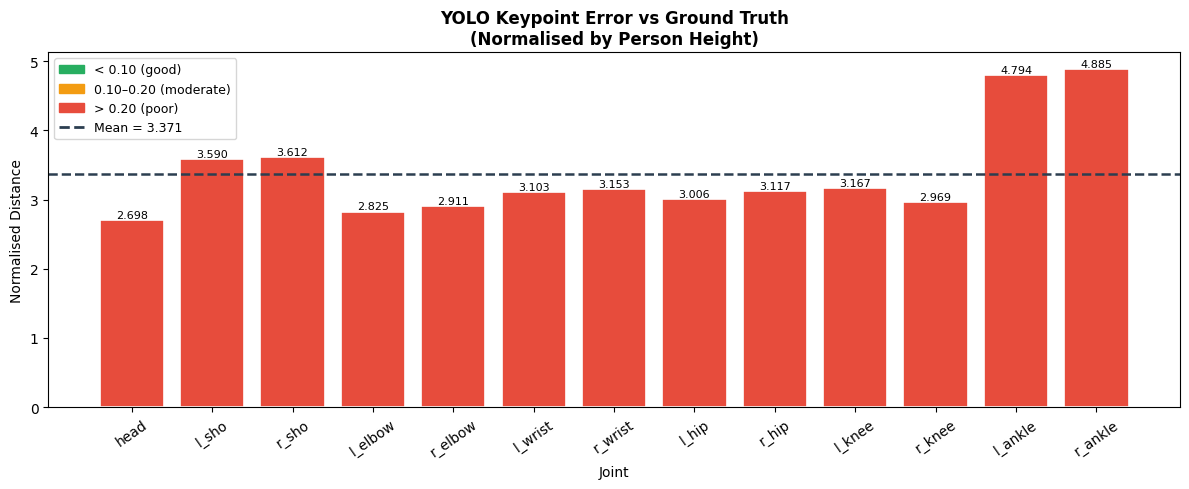

In [ ]:
# ── Task 3 — Metric 1: YOLO Keypoint Quality vs Ground Truth ─────────
# Per-joint Euclidean distance normalised by person height.
# Runs YOLO on ALL exercise videos (keypoint quality is training-split agnostic).

JOINT_NAMES_13 = [
    'head','l_sho','r_sho','l_elbow','r_elbow',
    'l_wrist','r_wrist','l_hip','r_hip',
    'l_knee','r_knee','l_ankle','r_ankle'
]

print('Evaluating YOLO keypoint quality vs .mat ground truth...')
print('(Running YOLO on every exercise video — this takes several minutes)\n')

per_video_errors = []
n_skipped = 0

# Import tqdm for progress bar
from tqdm.notebook import tqdm

for mat_file in tqdm(mat_files_all, desc='Evaluating YOLO keypoint quality'):
    md = scipy.io.loadmat(mat_file)
    action = md['action'][0]
    if isinstance(action, np.ndarray): action = action[0]
    if str(action) not in exercise_classes:
        continue

    vid_id = os.path.splitext(os.path.basename(mat_file))[0]
    frame_paths = sorted(glob.glob(os.path.join(FRAMES_DIR, vid_id, '*.jpg')))
    if not frame_paths:
        n_skipped += 1; continue

    # Ground truth: (T, 13, 2) raw pixel coords
    gt_kpts = np.stack((md['x'], md['y']), axis=-1)  # (T, 13, 2)
    gt_aligned = temporal_align(gt_kpts, 64)          # (64, 13, 2)

    # YOLO: run on each frame, collect 13 Penn Action joints
    yolo_seq = []
    for fp in frame_paths:
        res = model_yolo(fp, verbose=False)
        if res[0].keypoints is not None and len(res[0].keypoints.xy) > 0:
            kp17 = res[0].keypoints.xy[0].cpu().numpy()
            yolo_seq.append(kp17[COCO_TO_PENN_IDX])  # (13, 2)
        else:
            yolo_seq.append(np.zeros((13, 2)))
    yolo_kpts   = np.array(yolo_seq)           # (T, 13, 2)
    yolo_aligned = temporal_align(yolo_kpts, 64)  # (64, 13, 2)

    # Only evaluate frames where YOLO actually detected someone
    valid = yolo_aligned.sum(axis=(1, 2)) > 0  # (64,)
    if valid.sum() < 10:
        n_skipped += 1; continue

    gt_v   = gt_aligned[valid]    # (V, 13, 2)
    yolo_v = yolo_aligned[valid]

    # Normalise by person height: head (joint 0) to mean ankle (joints 11,12)
    head_y   = gt_v[:, 0, 1].mean()
    ankle_y  = ((gt_v[:, 11, 1] + gt_v[:, 12, 1]) / 2).mean()
    height   = max(abs(ankle_y - head_y), 1.0)

    dist = np.sqrt(((yolo_v - gt_v) ** 2).sum(axis=-1))  # (V, 13)
    per_video_errors.append((dist / height).mean(axis=0))  # (13,)

print(f'Evaluated : {len(per_video_errors)} videos')
print(f'Skipped   : {n_skipped} (no frames or no YOLO detections)\n')

mean_per_joint = np.mean(per_video_errors, axis=0)  # (13,)
overall_mean   = mean_per_joint.mean()
print(f'Overall mean normalised joint error: {overall_mean:.4f}')
print('Per-joint errors:')
for name, err in zip(JOINT_NAMES_13, mean_per_joint):
    print(f'  {name:<10}: {err:.4f}')

# Bar chart
from matplotlib.patches import Patch
bar_colors = ['#27ae60' if e < 0.10 else '#f39c12' if e < 0.20 else '#e74c3c'
              for e in mean_per_joint]
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(JOINT_NAMES_13, mean_per_joint, color=bar_colors,
              edgecolor='white', linewidth=1.2)
ax.axhline(overall_mean, color='#2c3e50', linestyle='--', linewidth=1.8)
ax.set_title('YOLO Keypoint Error vs Ground Truth\n(Normalised by Person Height)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Joint'); ax.set_ylabel('Normalised Distance')
ax.tick_params(axis='x', rotation=35)
for bar, e in zip(bars, mean_per_joint):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{e:.3f}', ha='center', va='bottom', fontsize=8)
ax.legend(handles=[
    Patch(color='#27ae60', label='< 0.10 (good)'),
    Patch(color='#f39c12', label='0.10–0.20 (moderate)'),
    Patch(color='#e74c3c', label='> 0.20 (poor)'),
    plt.Line2D([0],[0], color='#2c3e50', linewidth=2, linestyle='--',
               label=f'Mean = {overall_mean:.3f}'),
], fontsize=9)
plt.tight_layout()
plt.savefig('yolo_keypoint_quality.png', dpi=150, bbox_inches='tight')
plt.show()

Val set size: 233 videos
Running YOLO + ST-GCN on val set... (takes several minutes)



Processing validation videos:   0%|          | 0/233 [00:00<?, ?it/s]

Evaluated: 233  |  Failed (no frames): 0

Accuracy  : 0.7382
Macro F1  : 0.7239

--- Classification Report ---
                precision    recall  f1-score   support

   bench_press       0.78      0.25      0.38        28
clean_and_jerk       0.75      0.83      0.79        18
     jump_rope       0.70      0.88      0.78        16
 jumping_jacks       0.92      0.96      0.94        23
        pullup       1.00      0.88      0.93        40
        pushup       0.76      0.60      0.67        42
         situp       0.36      0.80      0.49        20
         squat       0.81      0.83      0.82        46

      accuracy                           0.74       233
     macro avg       0.76      0.75      0.72       233
  weighted avg       0.79      0.74      0.74       233



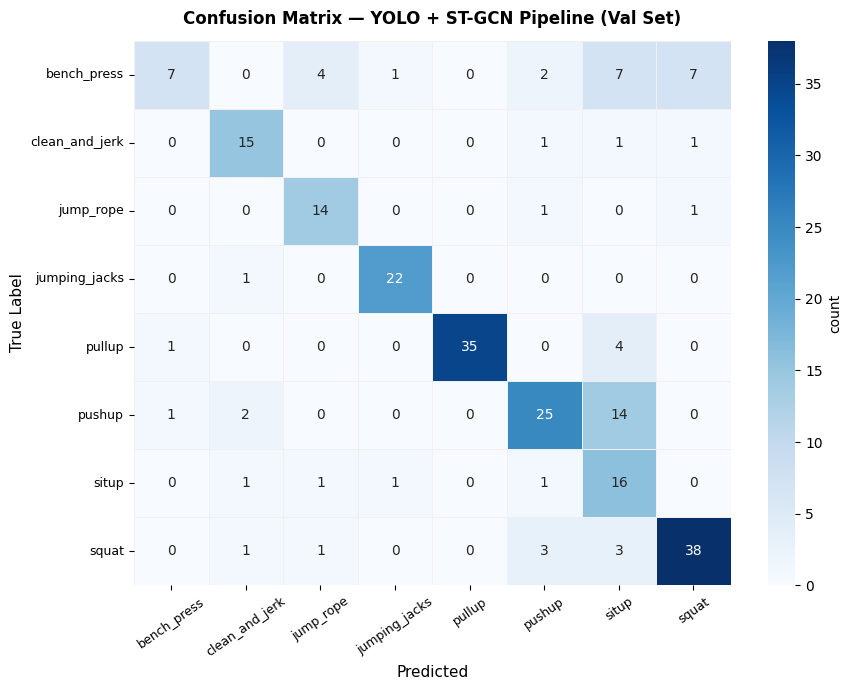

In [ ]:
# ── Task 3 — Metric 2: Full Pipeline Classification ──────────────────
# Re-create the same 20% val split used during training (random_state=42)
# then run YOLO + ST-GCN on every val video and report classification metrics.

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, classification_report)
import seaborn as sns
from tqdm.notebook import tqdm # Import tqdm for progress bar

# Build exercise file list + labels (same order as training notebook)
mat_exercise, labels_exercise = [], []
for mf in mat_files_all:
    md = scipy.io.loadmat(mf)
    action = md['action'][0]
    if isinstance(action, np.ndarray): action = action[0]
    action = str(action)
    if action in exercise_classes:
        mat_exercise.append(mf)
        labels_exercise.append(class_to_id[action])

_, mat_val, _, lbl_val = train_test_split(
    mat_exercise, labels_exercise,
    test_size=0.2, random_state=42, stratify=labels_exercise
)
print(f'Val set size: {len(mat_val)} videos')
print('Running YOLO + ST-GCN on val set... (takes several minutes)\n')

all_preds, all_gt = [], []
n_failed = 0

# Add tqdm to the loop for progress indication
for mat_file, gt_label in tqdm(zip(mat_val, lbl_val), total=len(mat_val), desc='Processing validation videos'):
    vid_id = os.path.splitext(os.path.basename(mat_file))[0]
    kpts_aligned, _ = extract_yolo_keypoints(FRAMES_DIR, vid_id, model_yolo)
    if kpts_aligned is None:
        n_failed += 1; continue
    pred_idx, _ = run_stgcn_inference(kpts_aligned, model_stgcn, device)
    all_preds.append(pred_idx)
    all_gt.append(gt_label)

print(f'Evaluated: {len(all_preds)}  |  Failed (no frames): {n_failed}\n')

acc = accuracy_score(all_gt, all_preds)
f1  = f1_score(all_gt, all_preds, average='macro', zero_division=0)
print(f'Accuracy  : {acc:.4f}')
print(f'Macro F1  : {f1:.4f}')
print('\n--- Classification Report ---')
print(classification_report(all_gt, all_preds,
                             target_names=exercise_classes, zero_division=0))

# Confusion matrix
conf_mat = confusion_matrix(all_gt, all_preds)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=exercise_classes, yticklabels=exercise_classes,
            linewidths=0.5, linecolor='#f0f0f0', ax=ax,
            cbar_kws={'label': 'count'})
ax.set_title('Confusion Matrix — YOLO + ST-GCN Pipeline (Val Set)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.tick_params(axis='x', rotation=35, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.savefig('pipeline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()